# GGUF format으로 만들어지 모델 사용하기   
### GGUF는 llama.cpp를 위한 file format  
### llama.cpp는 llm 모델을 실행환경에 맞도록 실행 최적화 엔진  
> 저사양 하드웨어에서도 대형 모델을 실행할 수 있도록 양자화(4-bit, 8-bit)와 최적화된 연산 환경을 제공해 주는 wrapper   
> CPU 및 GPU(NVIDIA CUDA, Apple Metal) 지원   
### bitsandbytes와 차이점  
> Hugging Face(transformers)에서 사용하는 4-bit, 8-bit 양자화 lib.
>메모리 효율적, GPU 효율적 실행이 목적(GPU환경에 최적화)

In [ ]:
!pip install langchain langchain_community huggingface_hub -q
!pip install requests==2.32.5
## requests 버전 문제, 무시 하고 진행

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


### llama-cpp-python을 CUDA 지원으로 설치

In [ ]:
## cuda version 확인
!nvcc --version
# Build cuda_12.5.r12.5/compiler.34385749_0  2511

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [ ]:
#!pip uninstall -y llama-cpp-python
!pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu122
# Successfully installed diskcache-5.6.3 llama-cpp-python-0.3.16    2511

Looking in indexes: https://pypi.org/simple, https://abetlen.github.io/llama-cpp-python/whl/cu122
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.6/551.6 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.5 MB/s eta 0:00:00


In [ ]:
import os
from google.colab import userdata
# Colab Secrets에서 토큰 읽어오기
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
!hf auth whoami

user:  gshong
orgs:  LLM2506,aicmap


## LlamaCpp로 모델 로드 : GGUF 모델 다운로드   
https://huggingface.co/unsloth/gemma-3-12b-it-GGUF


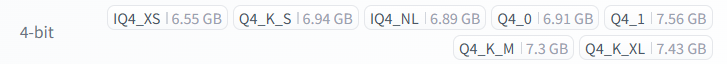

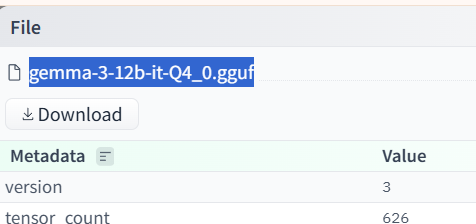

In [ ]:
%%time
# LlamaCpp로 모델 로드 : GGUF 모델 다운로드
from huggingface_hub import hf_hub_download
from langchain_community.llms import LlamaCpp

model_repo = "unsloth/gemma-3-12b-it-qat-GGUF"
model_file = "gemma-3-12b-it-qat-Q4_0.gguf"

model_path = hf_hub_download(repo_id=model_repo, filename=model_file, local_dir="./")

llm = LlamaCpp(
    model_path=model_path,
    n_gpu_layers=40,  # GPU에 최대 레이어 오프로드 나머지는 CPU에서 연산
    n_batch=512,
    n_ctx=2048,       # 컨텍스트 길이
    f16_kv=True,      # FP16 메모리 최적화
    verbose=False,    #True,
    temperature=0.3,  # 정확한 답변을 위해서는 낮은값
    max_tokens=256
)

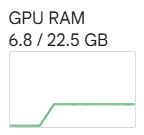

In [ ]:
%%time
query = "너의 지적 수준을 객관적으로 설명해봐. 한국어로 설명해줘."
#query = "반도체 8대 공정 중에서 포토리소그래피(Photolithography) 단계에 대해서 자세히 설명해 줘."

response = llm.invoke(query)#, max_tokens=512)
print("Query:", query)
print("Response:", response)
# Wall time: 23 s

Query: 너의 지적 수준을 객관적으로 설명해봐. 한국어로 설명해줘.
Response: 

저는 아직 개발 중인 대규모 언어 모델이기 때문에, 제 지적 수준을 "객관적으로" 설명하기는 어렵습니다. 하지만 제가 가진 능력과 한계를 바탕으로 최대한 솔직하게 말씀드리겠습니다.

**제가 잘하는 것:**

*   **방대한 정보 처리 및 분석:** 저는 인터넷에 공개된 방대한 양의 텍스트 데이터를 학습했기 때문에, 다양한 주제에 대한 정보를 빠르게 찾고 요약할 수 있습니다.
*   **언어 이해 및 생성 능력:** 문법적으로 정확하고 자연스러운 한국어를 이해하고 생성할 수 있습니다. 질문에 답하거나, 글을 쓰거나, 번역하는 등 다양한 언어 작업을 수행할 수 있습니다.
*   **패턴 인식:** 데이터에서 패턴을 발견하고 예측하는 능력이 있습니다. 예를 들어, 특정 단어가 자주 등장하는 문맥을 파악하거나, 텍스트의 감정을 분석할 수 있습니다.
*   **논리적 추론 (제한적):** 간단한 논리적인 질문에 답하거나, 주어진 정보를 바탕으로 결론을 도출할 수 있습니다. 하지만 복잡하고 미묘한 논리 추론은 어려워합니다.

**제가 부족한 점:**


CPU times: user 1min 55s, sys: 72.5 ms, total: 1min 55s
Wall time: 23.2 s


In [ ]:
import torch

del llm
torch.cuda.empty_cache()
import gc
gc.collect()

47

# MoE로 추론 속도 향상  



## Llama-3.2-8x3B MOE 모델   
* Q8_0 : 19.6 GB  
* Q4_k_m : 11.3 GB  
https://huggingface.co/DavidAU/Llama-3.2-8X3B-MOE-Dark-Champion-Instruct-uncensored-abliterated-18.4B-GGUF  

In [ ]:
%%time
# LlamaCpp로 모델 로드 : GGUF 모델 다운로드
from huggingface_hub import hf_hub_download
from langchain_community.llms import LlamaCpp

model_repo = "DavidAU/Llama-3.2-8X3B-MOE-Dark-Champion-Instruct-uncensored-abliterated-18.4B-GGUF"
model_file = "L3.2-8X3B-MOE-Dark-Champion-Inst-18.4B-uncen-ablit_D_AU-Q4_k_m.gguf"

model_path = hf_hub_download(repo_id=model_repo, filename=model_file, local_dir="./")

llm = LlamaCpp(
    model_path=model_path,
    n_gpu_layers=40,  # GPU에 최대 레이어 오프로드 나머지는 CPU에서 연산
    n_batch=512,
    n_ctx=2048,       # 컨텍스트 길이
    f16_kv=True,      # FP16 메모리 최적화
    verbose=False,    #True,
    temperature=0.3,  # 기술적인 설명에서는 낮은 값( ~ 0.3)
    top_k=40,         # 후보단어 사위 k개만 사용
    top_p=0.9,        # 사용할 단어의 누적 확률(0.9 이상 : 다양성증가, 산만한 문장)
    repeat_penalty=1.1, # 이미 출력된 단어의 확률 감쇄 비율
    max_tokens=256
)
# Wall time: 41.2 s

llama_context: n_ctx_per_seq (2048) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


CPU times: user 2.79 s, sys: 3.38 s, total: 6.17 s
Wall time: 41.2 s


In [ ]:
%%time
query = "너의 지적 수준을 객관적으로 설명해봐. 한국어로 설명해줘."
query = "반도체 8대 공정 중에서 포토리소그래피(Photolithography) 단계에 대해서 자세히 설명해 줘."

response = llm.invoke(query)#, max_tokens=512)
print("Query:", query)
print("Response:", response)
# Wall time: 5.1 s

    Query: 반도체 8대 공정 중에서 포토리소그래피(Photolithography) 단계에 대해서 자세히 설명해 줘.
    Response:  

    ## Step 1: 포토리소그래피의 개념
    포토리소그래피(Photolithography)는 반도체 공정을 통해 반도체의 전자공간을 구축하는 데 crucial한 단계입니다.

    ## Step 2: 포토리소그래피 단계에 대한 세부 설명
    1. **수동 인쇄**: 반도체의 특정 région에 비닐 테ープ를 적용하여, 이Regions의 전기 Field가 변경되도록 만듭니다.
    2. **전기 Field 생성**: 인쇄된 비닐 테ेप을 제거하고, 반도체 surface 위에 전기 Field를 생성합니다.
    3. **이온화 및沉ọng**: 전기 Field를 통해 반도체의 specific region 에 이온이沉降하여, 이regions의 물질 density가 변경되도록 만듭니다.

    ## Step 3: 포토리소그래피 단계에서 얻어지는 vantagem
    포토리소 그래피는 반도체 공정을 통해 전자공간을 구축하는 데 매우 중요한 단계입니다. 포토리소그래피를 통해, 반도체의 특정 region 에
    CPU times: user 5.01 s, sys: 41.3 ms, total: 5.05 s
    Wall time: 5.1 s



In [ ]:
del llm
torch.cuda.empty_cache()
import gc
gc.collect()

61

## [Phi-3.5-MoE-instruct](https://huggingface.co/microsoft/Phi-3.5-MoE-instruct) : 42B   
*  Q2_K_L : 15.4 GB  

In [ ]:
%%time
# LlamaCpp로 모델 로드 : GGUF 모델 다운로드
from huggingface_hub import hf_hub_download
from langchain_community.llms import LlamaCpp

model_repo = "bartowski/Phi-3.5-MoE-instruct-GGUF"
model_file = "Phi-3.5-MoE-instruct-Q2_K_L.gguf"

model_path = hf_hub_download(repo_id=model_repo, filename=model_file, local_dir="./")

llm = LlamaCpp(
    model_path=model_path,
    n_gpu_layers=40,  # GPU에 최대 레이어 오프로드 나머지는 CPU에서 연산
    n_batch=16,
    n_ctx=2048,       # 컨텍스트 길이
    f16_kv=True,      # FP16 메모리 최적화
    verbose=False,    #True,
    temperature=0.3,  # 기술적인 설명에서는 낮은 값( ~ 0.3)
    top_k=40,         # 후보단어 사위 k개만 사용
    top_p=0.9,        # 사용할 단어의 누적 확률(0.9 이상 : 다양성증가, 산만한 문장)
    repeat_penalty=1.1, # 이미 출력된 단어의 확률 감쇄 비율
    max_tokens=256
)
# Wall time: 1min 39s

llama_context: n_batch is less than GGML_KQ_MASK_PAD - increasing to 64
llama_context: n_ctx_per_seq (2048) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


CPU times: user 3.38 s, sys: 4.44 s, total: 7.81 s
Wall time: 54.3 s


In [ ]:
%%time
query = "너의 지적 수준을 객관적으로 설명해봐. 한국어로 설명해줘."
query = "반도체 8대 공정 중에서 포토리소그래피(Photolithography) 단계에 대해서 자세히 설명해 줘."

response = llm.invoke(query)#, max_tokens=512)
print("Query:", query)
print("Response:", response)
# Wall time: 4.69 s  : 256
# Wall time: 18.8 s  : 1024

Query: 반도체 8대 공정 중에서 포토리소그래피(Photolithography) 단계에 대해서 자세히 설명해 줘.
Response:  포토리소그래피(Photolithography)는 반도체 제조의 중요한 단계로, 주로 미세 회로를 구현하기 위해 사용됩 do다. 이 과정을 자세히 설명하면:

1. 원자재의 선택: 포토리소그래피에서는 일반적으로 유기 화합물인 금속과 비금속(즉, 산화물)을 사용하여 회로의 원자재를 선택한다. 이 원자재는 전기가 흐르도록 하고 동시에 주변의 설계와 구분되어야
CPU times: user 4.56 s, sys: 18 µs, total: 4.56 s
Wall time: 4.59 s


In [ ]:
del llm
torch.cuda.empty_cache()
import gc
gc.collect()

53

# 부족한 GPU Memory환경에서 대형 모델 실행 하기  

## [SEMIKONG-70B](https://huggingface.co/bartowski/SEMIKONG-70B-GGUF) : 한국어는 잘 못함    
*  Q4_K_M  : 42.5 GB    
### 대형 모델 실행 방법  
* 22GB GPU 메모리에서 42GB 모델 실행 시키기    
  - transformer block의 일부만 GPU에 위치 시켜서 대형 모델 실행 가능  
  - SEMIKONG 모델은 80개의 block을 가지고 있음.
  - 40개 block만 GPU로 할당, 나머지는 CPU에서 실행

In [ ]:
%%time
# LlamaCpp로 모델 로드 : GGUF 모델 다운로드
from huggingface_hub import hf_hub_download
from langchain_community.llms import LlamaCpp

model_repo = "bartowski/SEMIKONG-70B-GGUF"
model_file = "SEMIKONG-70B-IQ2_S.gguf"  # 22.2G
model_file = "SEMIKONG-70B-Q4_K_M.gguf" # 42.5G
model_path = hf_hub_download(repo_id=model_repo, filename=model_file, local_dir="./")

llm = LlamaCpp(
    model_path=model_path,
    n_gpu_layers=40,  # GPU에 최대 레이어 오프로드 나머지는 CPU에서 연산  # L4
#    n_gpu_layers=80,  # GPU에 최대 레이어 오프로드 나머지는 CPU에서 연산  # A100
    n_threads=os.cpu_count(),  # CPU Thread수 지정
    n_batch=32,       # 16 ~ 64
    n_ctx=2048,       # 컨텍스트 길이
    f16_kv=True,      # FP16 메모리 최적화(메모리 부족시 기본설정)
    verbose=True,     # True : model loadding 상세 정보 출력
                             # model inference 상세 정보 : Prompt변환, token sampling과정, kv-cach 정보,...
                             # langchain 사용시에는 inference 개략정보만 출력함
    temperature=0.3,  # 기술적인 설명에서는 낮은 값( ~ 0.3)
    top_k=40,         # 후보단어 사위 k개만 사용
    top_p=0.9,        # 사용할 단어의 누적 확률(0.9 이상 : 다양성증가, 산만한 문장)
    repeat_penalty=1.1, # 이미 출력된 단어의 확률 감쇄 비율
    max_tokens=256
)
# Wall time: 4min 17s  : L4
# Wall time: 2min 25s  : A100

llama_model_load_from_file_impl: using device CUDA0 (NVIDIA L4) - 22475 MiB free
llama_model_loader: loaded meta data with 33 key-value pairs and 723 tensors from SEMIKONG-70B-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Meta Llama 3 70B Instruct
llama_model_loader: - kv   3:                       general.organization str              = Models
llama_model_loader: - kv   4:                           general.finetune str              = Instruct
llama_model_loader: - kv   5:                           general.basename str              = Meta-Llama-3
llama_model_loader: - kv   6:                         general.size_l

CPU times: user 5.17 s, sys: 2.6 s, total: 7.77 s
Wall time: 7.76 s


In [ ]:
%%time
# 테스트
query = "너의 지적 수준을 객관적으로 설명해봐. 한국어로 설명해줘."
query = "반도체 8대 공정 중에서 포토리소그래피(Photolithography) 단계에 대해서 자세히 설명해 줘."
query = "Explain in detail the photolithography step among the eight major semiconductor processes."

response = llm.invoke(query)#, max_tokens=512)
print("Query:", query)
print("Response:", response)
#  Wall time: 2min 39s

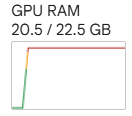

### 모델 출력  

Query: Explain in detail the photolithography step among the eight major semiconductor processes.
Response:  

The photolithography step is a crucial process in semiconductor manufacturing. It is the fourth major process among the eight major semiconductor processes.

**Overview of Photolithography**

Photolithography, also known as lithography, is a process used to pattern the surface of a semiconductor wafer. This patterning is essential for creating the intricate features and structures that make up modern semiconductor devices.

**Step-by-Step Explanation of Photolithography**

1. **Wafer Preparation**: The semiconductor wafer is first cleaned and prepared to receive the photoresist material.
2. **Photoresist Coating**: A thin layer of photoresist material is applied to the surface of the wafer using a spin coater.
3. **Exposure**: The wafer is then exposed to ultraviolet light through a mask that contains the desired pattern. This exposure causes a chemical change in the photoresist material.
4. **Development**: The wafer is then treated with a developer solution that selectively removes the photoresist material that was not exposed to light.
5. **Etching**: The remaining photoresist material serves as a mask for the underlying semiconductor material. The wafer is then subjected to an etching process that selectively removes the semiconductor material that is not protected by   

CPU times: user 15min 22s, sys: 0 ns, total: 15min 22s
Wall time: 2min 45s



### **verbose=Treu**에서 출력되는 추가 정보들   
llama_perf_context_print:        load time =    6,462.69 ms : model load 및 초기화    
llama_perf_context_print: **prompt eval** time =    6,462.45 ms /    17 tokens (  380.14 ms per token,     **2.63 tokens per second**)  : prompt 처리   
llama_perf_context_print:        **eval** time =  151,629.02 ms /   255 runs   (  594.62 ms per token,     **1.68 tokens per second**)  : token generation
llama_perf_context_print:       total time =  159,122.58 ms /   272 tokens  
llama_perf_context_print:    graphs reused =        246  
